In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

# Set random seeds for reproducibility
np.random.seed(1)
tf.random.set_seed(1)
random.seed(1)

%matplotlib inline

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to add channel dimension (28, 28, 1) for Conv2D
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
# gaussian noise
noise_factor = 0.35
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape, seed=1)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape, seed=1)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0.0, 1.0)
x_test_noisy = tf.clip_by_value(x_test_noisy, 0.0, 1.0)

print(f"Noisy training data shape: {x_train_noisy.shape}")
print(f"Noisy test data shape: {x_test_noisy.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Noisy training data shape: (60000, 28, 28, 1)
Noisy test data shape: (10000, 28, 28, 1)


## 2. Define Convolutional Autoencoder Class

In [ ]:
class ConvAutoencoder(keras.Model):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        
        # 2 Conv2D layers
        self.encoder = keras.Sequential([
            layers.Conv2D(8, (3, 3), activation='relu', strides=2, padding='same', 
                         input_shape=(28, 28, 1)),  # Output: 14x14x8
            layers.Conv2D(4, (3, 3), activation='relu', strides=2, padding='same')  # Output: 7x7x4
        ])
        
        # 2 Conv2DTranspose layers + final Conv2D
        self.decoder = keras.Sequential([
            layers.Conv2DTranspose(4, (3, 3), activation='relu', strides=2, 
                                  padding='same', input_shape=(7, 7, 4)),  # Output: 14x14x4
            layers.Conv2DTranspose(8, (3, 3), activation='relu', strides=2, 
                                  padding='same'),  # Output: 28x28x8
            layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')  # Output: 28x28x1
        ])
    
    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = ConvAutoencoder()

# Build the model by calling it
_ = autoencoder(x_train[:1])


encoded_shape = autoencoder.encoder(x_train[:1]).shape
print(f"Encoder output shape (bottleneck): {encoded_shape}")

autoencoder.encoder.summary()
print("\n" + "="*60 + "\n")
autoencoder.decoder.summary()

Encoder output shape (bottleneck): (1, 7, 7, 4)


e:\master\AnomalyDetection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
e:\master\AnomalyDetection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 4)        │           292 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372 (1.45 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 14, 14, 4)      │           148 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 8)      │           296 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 517 (2.02 KB)

 Trainable params: 517 (2.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0286 - val_loss: 0.0054
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0023 - val_loss: 0.0022


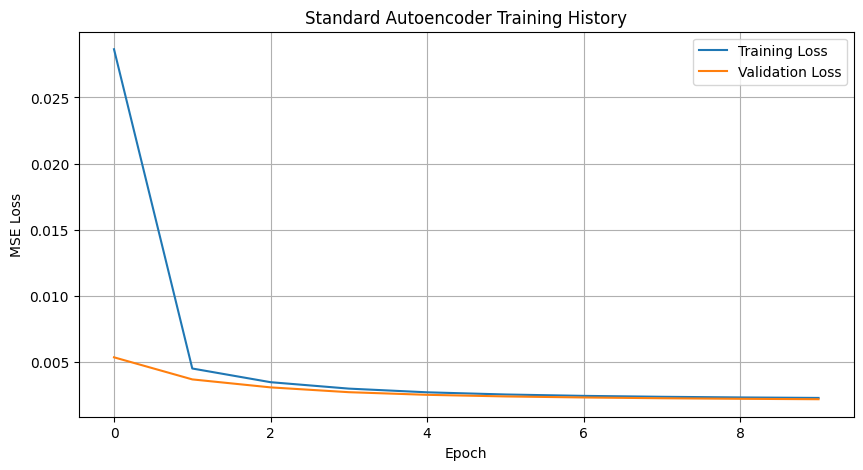

In [4]:
autoencoder.compile(optimizer='adam', loss='mse')

# clean data only (input = output)
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Standard Autoencoder Training History')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Reconstruct training data
recon_train = autoencoder.predict(x_train, verbose=0)

# Compute reconstruction errors (MSE per sample)
mse_train = np.mean(np.square(x_train - recon_train), axis=(1, 2, 3))

# Compute threshold
threshold = np.mean(mse_train) + np.std(mse_train)
print(f"Threshold (mean + std): {threshold:.6f}")
print(f"Mean reconstruction error (train): {np.mean(mse_train):.6f}")
print(f"Std reconstruction error (train): {np.std(mse_train):.6f}")

Threshold (mean + std): 0.003399
Mean reconstruction error (train): 0.002279
Std reconstruction error (train): 0.001121


In [6]:
recon_test_clean = autoencoder.predict(x_test, verbose=0)
mse_test_clean = np.mean(np.square(x_test - recon_test_clean), axis=(1, 2, 3))

recon_test_noisy = autoencoder.predict(x_test_noisy, verbose=0)
mse_test_noisy = np.mean(np.square(x_test_noisy - recon_test_noisy), axis=(1, 2, 3))

# Classify (0 = normal, 1 = anomaly)
pred_clean = (mse_test_clean > threshold).astype(int)
pred_noisy = (mse_test_noisy > threshold).astype(int)

# Clean images should be normal (0), noisy images should be anomalies (1)
true_labels_clean = np.zeros(len(x_test))
true_labels_noisy = np.ones(len(x_test_noisy))

acc_clean = np.mean(pred_clean == true_labels_clean)
acc_noisy = np.mean(pred_noisy == true_labels_noisy)
combined_acc = np.mean(np.concatenate([pred_clean, pred_noisy]) == 
                       np.concatenate([true_labels_clean, true_labels_noisy]))

print("\n" + "="*60)
print("STANDARD AUTOENCODER - ANOMALY DETECTION RESULTS")
print("="*60)
print(f"Accuracy on clean test images: {acc_clean:.4f} ({np.sum(pred_clean == 0)}/{len(pred_clean)} correctly classified as normal)")
print(f"Accuracy on noisy test images: {acc_noisy:.4f} ({np.sum(pred_noisy == 1)}/{len(pred_noisy)} correctly classified as anomaly)")
print(f"Overall accuracy: {combined_acc:.4f}")
print(f"\nMean reconstruction error (clean test): {np.mean(mse_test_clean):.6f}")
print(f"Mean reconstruction error (noisy test): {np.mean(mse_test_noisy):.6f}")


STANDARD AUTOENCODER - ANOMALY DETECTION RESULTS
Accuracy on clean test images: 0.8838 (8838/10000 correctly classified as normal)
Accuracy on noisy test images: 1.0000 (10000/10000 correctly classified as anomaly)
Overall accuracy: 0.9419

Mean reconstruction error (clean test): 0.002205
Mean reconstruction error (noisy test): 0.049351


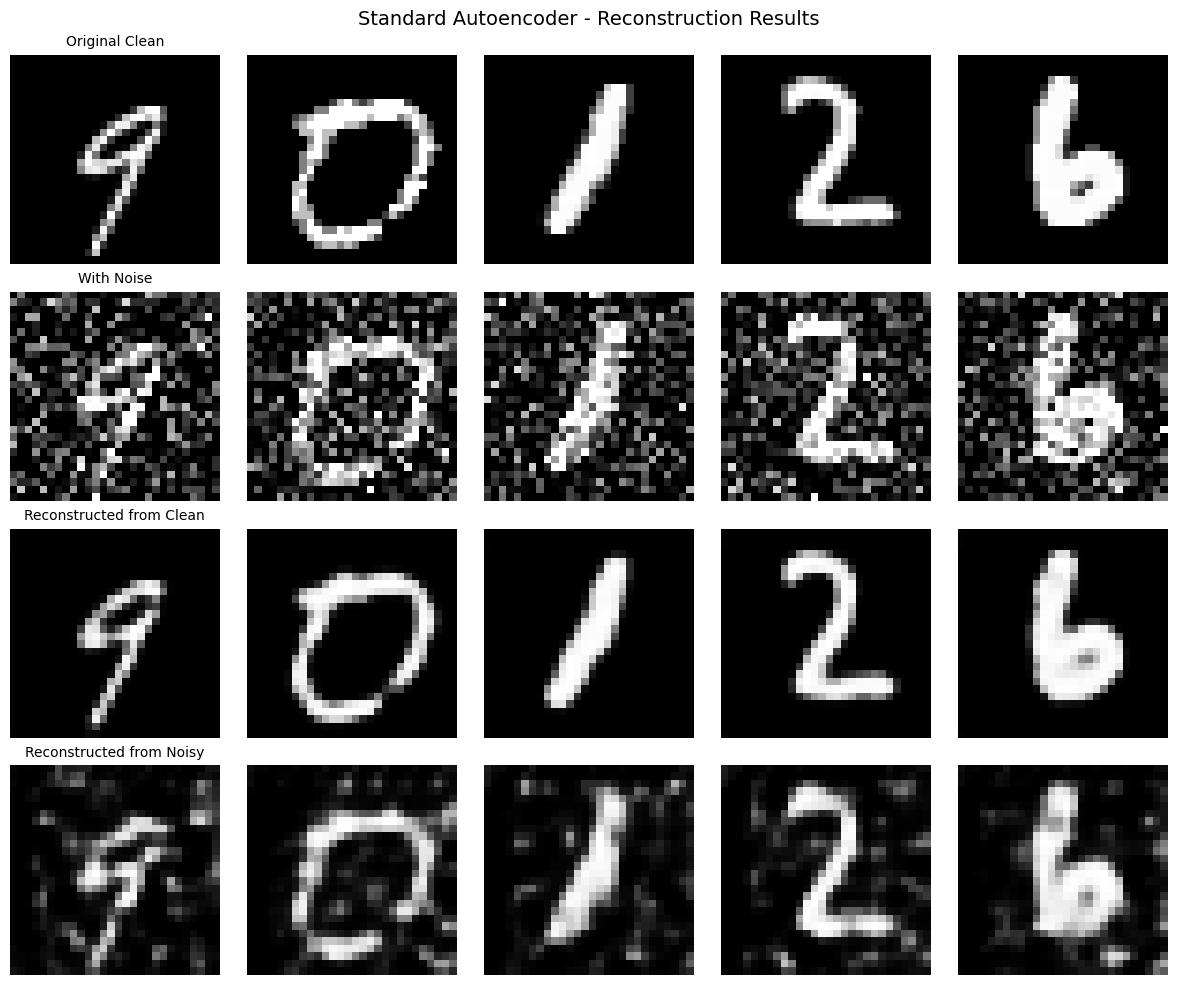

In [10]:
n_images = 5
indices = np.random.choice(len(x_test), n_images, replace=False)

# Create figure with 4 rows
fig, axes = plt.subplots(4, n_images, figsize=(12, 10))

for i, idx in enumerate(indices):
    # Row 1: Original clean images
    axes[0, i].imshow(x_test[idx].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original Clean', fontsize=10)
    
    # Row 2: Noisy images
    axes[1, i].imshow(x_test_noisy[idx], cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('With Noise', fontsize=10)
    
    # Row 3: Reconstructed from clean
    axes[2, i].imshow(recon_test_clean[idx].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Reconstructed from Clean', fontsize=10)
    
    # Row 4: Reconstructed from noisy
    axes[3, i].imshow(recon_test_noisy[idx].squeeze(), cmap='gray')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_title('Reconstructed from Noisy', fontsize=10)

plt.suptitle('Standard Autoencoder - Reconstruction Results', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## Train Denoising Autoencoder

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1174 - val_loss: 0.1140
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1120 - val_loss: 0.1140


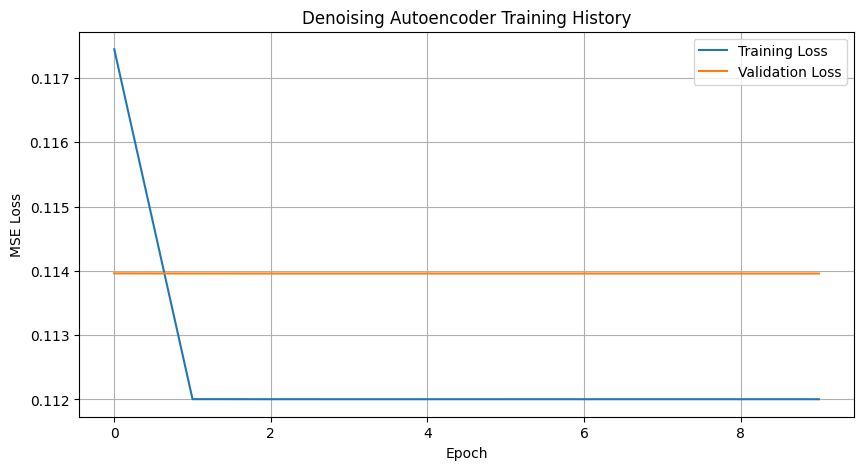

In [ ]:
# new denoising autoencoder
denoising_autoencoder = ConvAutoencoder()

denoising_autoencoder.compile(optimizer='adam', loss='mse')

# Train on noisy - clean mapping 
history_denoising = denoising_autoencoder.fit(
    x_train_noisy, x_train,  
    epochs=10,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test_noisy, x_test), 
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_denoising.history['loss'], label='Training Loss')
plt.plot(history_denoising.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Denoising Autoencoder Training History')
plt.legend()
plt.grid(True)
plt.show()

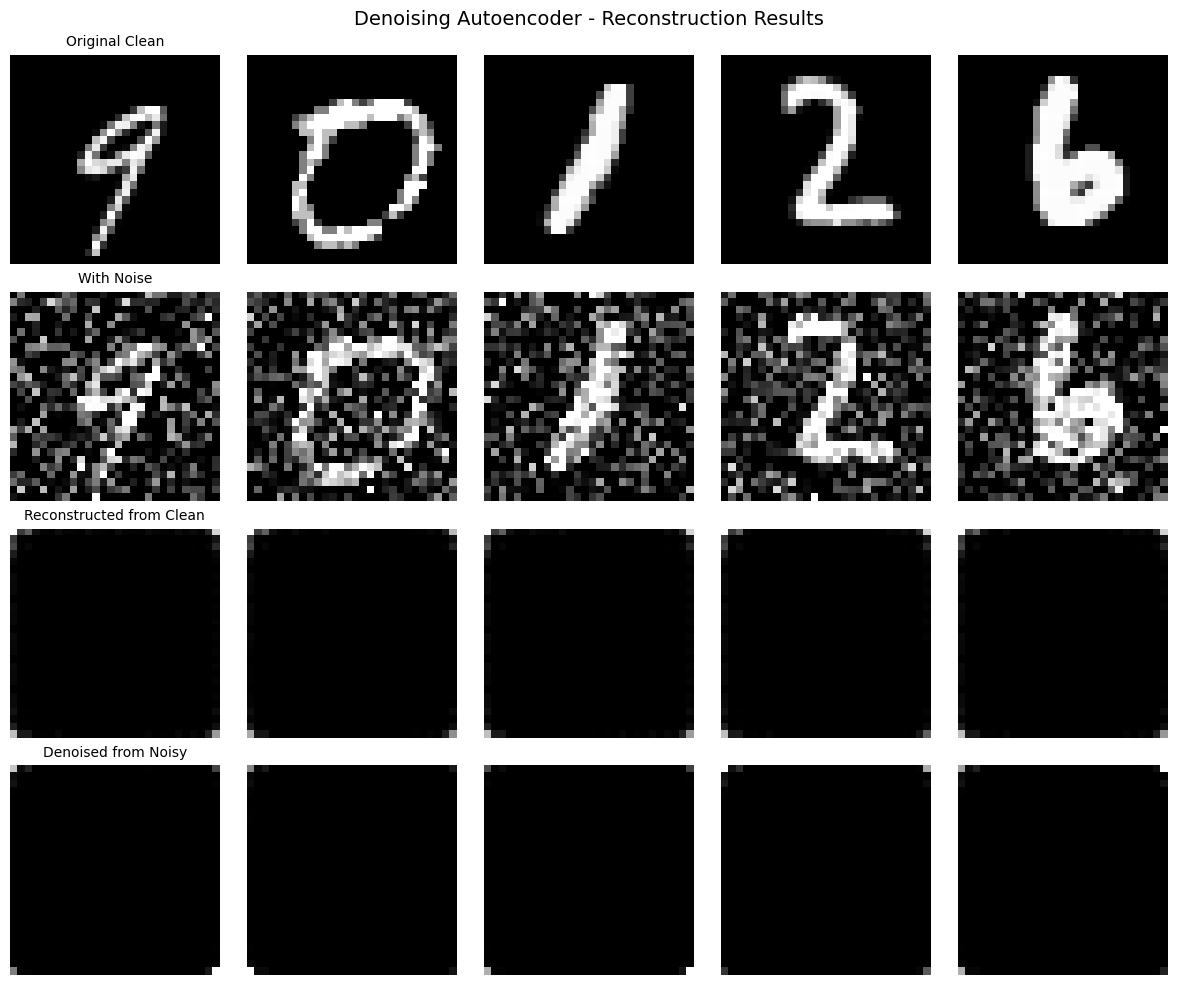

Mean reconstruction error : 0.113960
Mean reconstruction error : 0.113958


In [16]:
recon_test_clean_denoising = denoising_autoencoder.predict(x_test, verbose=0)
recon_test_noisy_denoising = denoising_autoencoder.predict(x_test_noisy, verbose=0)

fig, axes = plt.subplots(4, n_images, figsize=(12, 10))

for i, idx in enumerate(indices):
    axes[0, i].imshow(x_test[idx], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original Clean', fontsize=10)
    
    axes[1, i].imshow(x_test_noisy[idx], cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('With Noise', fontsize=10)
    
    axes[2, i].imshow(recon_test_clean_denoising[idx], cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Reconstructed from Clean', fontsize=10)
    
    axes[3, i].imshow(recon_test_noisy_denoising[idx], cmap='gray')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_title('Denoised from Noisy', fontsize=10)

plt.suptitle('Denoising Autoencoder - Reconstruction Results', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

mse_clean_denoising = np.mean(np.square(x_test - recon_test_clean_denoising), axis=(1, 2, 3))
mse_noisy_denoising = np.mean(np.square(x_test - recon_test_noisy_denoising), axis=(1, 2, 3))

print(f"Mean reconstruction error : {np.mean(mse_clean_denoising):.6f}")
print(f"Mean reconstruction error : {np.mean(mse_noisy_denoising):.6f}")